In [14]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import os
import numpy as np
import pandas as pd
from tqdm import tqdm



In [15]:
class SingleRNN(nn.Module):
    def __init__(self,n_input,n_neurons):
        super(SingleRNN,self).__init__()
        
        self.Wx =  torch.randn(n_input,n_neurons)  # 4 X 1
        self.Wy = torch.randn(n_neurons,n_neurons)  # 1 X 1
        
        self.b = torch.zeros(1,n_neurons)  # 1 X 1
    def forward(self,X0,X1):
        self.Y0 = torch.tanh(torch.mm(X0,self.Wx) + self.b)  # 4 x 1
        self.Y1 = torch.tanh(torch.mm(self.Y0,self.Wy) + 
                             torch.mm(X1,self.Wx) + self.b)  # 4 x 1
        
        return self.Y0,self.Y1

N_input = 4
N_Neurons = 1

X0_batch = torch.tensor([[0,1,2,0],[3,4,5,0],[6,7,8,0],[9,0,1,0]],dtype=torch.float)   # t=0 => 4 X 4
X1_batch = torch.tensor([[9,8,7,0],[0,0,0,0],[6,5,4,0],[3,2,1,0]],dtype=torch.float)   # t=1 => 4 X 4

model = SingleRNN(N_input,N_Neurons)
Y0_val,Y1_val = model(X0_batch,X1_batch)

print("Y0_val = ",Y0_val)

Y0_val =  tensor([[ 0.9699],
        [ 0.9992],
        [ 1.0000],
        [-1.0000]])


In [16]:
rnn = nn.RNNCell(3, 5)

X_batch = torch.tensor([
    [[0,1,2],
     [3,4,5],
     [6,7,8],
     [9,0,1]],

    [[9,8,7],
     [0,0,0],
     [6,5,4],
     [3,2,1]]
], dtype=torch.float)

hx = torch.zeros(4, 5)      # batch_size = 4, hidden_size = 5

output = []

# Iterate over time steps
for i in range(2):
    hx = rnn(X_batch[i], hx)
    output.append(hx)

print("Output:")
for t, out in enumerate(output):
    print(f"Time step {t}:")
    print(out)

Output:
Time step 0:
tensor([[-0.4191, -0.7521,  0.5446,  0.5709, -0.2917],
        [-0.9162, -0.9023,  0.3331,  0.2746,  0.8558],
        [-0.9907, -0.9634,  0.0818, -0.0849,  0.9934],
        [-0.9607,  0.8042, -0.9034, -0.9971,  0.9151]],
       grad_fn=<TanhBackward0>)
Time step 1:
tensor([[-0.9966, -0.6193, -0.8986, -0.8753,  0.9990],
        [-0.2823,  0.0410, -0.0090, -0.1085, -0.0691],
        [-0.9770, -0.4798, -0.6965, -0.8717,  0.9911],
        [-0.6272, -0.7211, -0.0352, -0.2731,  0.4392]],
       grad_fn=<TanhBackward0>)


In [17]:
import torchvision
import torchvision.transforms as transforms

In [18]:
Batch_size = 64

#list all transformation
transform = transforms.Compose(
    [
        transforms.ToTensor()])

#download the training dataset

trainset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)

trainloader = torch.utils.data.DataLoader(trainset, batch_size=Batch_size, shuffle=True, num_workers=0)

#download the testing dataset
testset = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=Batch_size, shuffle=False, num_workers=0)


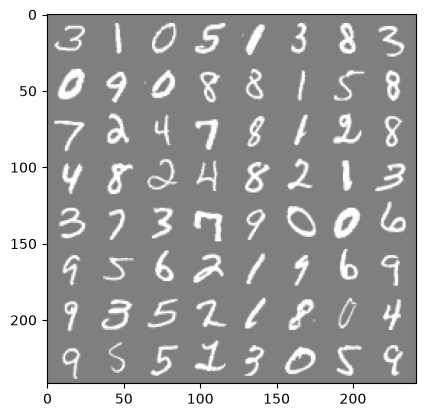

In [19]:
import matplotlib.pyplot as plt
import numpy as np

#fn to show an image

def imshow(img):
    img = img / 2 + 0.5     # unnormalize
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    
#get some random training images
data_iter = iter(trainloader)
images, labels = next(data_iter)

# show images
imshow(torchvision.utils.make_grid(images))

In [28]:
#parameters
N_steps = 28
N_input = 28
N_neurons = 150
N_output = 10
N_EPHOCS =10
Batch_size = 64

In [29]:
class ImageRNN(nn.Module):
    def __init__(self, batch_size, n_steps, n_inputs, n_neurons, n_outputs):
        super(ImageRNN, self).__init__()

        self.n_neurons = n_neurons
        self.batch_size = batch_size
        self.n_steps = n_steps
        self.n_inputs = n_inputs
        self.n_outputs = n_outputs

        self.basic_rnn = nn.RNN(self.n_inputs, self.n_neurons)

        self.FC = nn.Linear(self.n_neurons, self.n_outputs)

    def init_hidden(self,):
        # (num_layers, batch_size, n_neurons)
        return (torch.zeros(1, self.batch_size, self.n_neurons))

    def forward(self, X):
        # transforms X to dimensions: n_steps X batch_size X n_inputs
        X = X.permute(1, 0, 2)
        self.batch_size = X.size(1)
        self.hidden = self.init_hidden()
        # lstm_out => n_steps, batch_size, n_neurons (hidden states for each time step)
        # self.hidden => 1, batch_size, n_neurons (final state from each lstm_out)
        lstm_out, self.hidden = self.basic_rnn(X, self.hidden)
        out = self.FC(self.hidden)
        return out.view(-1, self.n_outputs) # batch_size X n_output

In [32]:
dataiter = iter(trainloader)
images, labels = next(dataiter)
model = ImageRNN(Batch_size, N_steps, N_input, N_neurons, N_output)
logits = model(images.view(-1, 28,28))
print(logits[0:10])

tensor([[ 0.0890, -0.0943, -0.0893, -0.0286,  0.0064,  0.0727, -0.0752,  0.0197,
         -0.0504, -0.0602],
        [ 0.0782, -0.0959, -0.0854, -0.0381,  0.0053,  0.0755, -0.0800,  0.0169,
         -0.0584, -0.0626],
        [ 0.0794, -0.1021, -0.0809, -0.0360,  0.0045,  0.0761, -0.0792,  0.0140,
         -0.0604, -0.0576],
        [ 0.0796, -0.1033, -0.0778, -0.0444,  0.0007,  0.0675, -0.0762,  0.0206,
         -0.0589, -0.0628],
        [ 0.1055, -0.1360, -0.0772, -0.0501, -0.0069,  0.0502, -0.0511,  0.0022,
         -0.0312, -0.0784],
        [ 0.0802, -0.0917, -0.0853, -0.0340,  0.0007,  0.0782, -0.0859,  0.0159,
         -0.0586, -0.0639],
        [ 0.0863, -0.0969, -0.0941, -0.0175,  0.0172,  0.0976, -0.0889,  0.0252,
         -0.0660, -0.0639],
        [ 0.0833, -0.0953, -0.0810, -0.0320,  0.0069,  0.0730, -0.0756,  0.0176,
         -0.0580, -0.0628],
        [ 0.0717, -0.0939, -0.0775, -0.0433,  0.0067,  0.0741, -0.0791,  0.0181,
         -0.0699, -0.0611],
        [ 0.0761, -

In [34]:
import torch.optim as optim
# Device
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
# Model instance
model = ImageRNN(Batch_size, N_steps, N_input, N_neurons, N_output)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
def get_accuracy(logit, target, batch_size):
    ''' Obtain accuracy for training round '''
    corrects = (torch.max(logit, 1)[1].view(target.size()).data == target.data).sum()
    accuracy = 100.0 * corrects/batch_size
    return accuracy.item()

In [36]:
for epoch in range(N_EPHOCS):  # loop over the dataset multiple times
    train_running_loss = 0.0
    train_acc = 0.0
    model.train()
    # TRAINING ROUND
    for i, data in enumerate(trainloader):
         # zero the parameter gradients
        optimizer.zero_grad()
        # reset hidden states
        model.hidden = model.init_hidden()
        # get the inputs
        inputs, labels = data
        inputs = inputs.view(-1, 28,28)
        # forward + backward + optimize
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        train_running_loss += loss.detach().item()
        train_acc += get_accuracy(outputs, labels, Batch_size)
    model.eval()
    print('Epoch:  %d | Loss: %.4f | Train Accuracy: %.2f'
          %(epoch, train_running_loss / i, train_acc/i))

Epoch:  0 | Loss: 0.8741 | Train Accuracy: 70.86
Epoch:  1 | Loss: 0.3838 | Train Accuracy: 88.81
Epoch:  2 | Loss: 0.2578 | Train Accuracy: 92.65
Epoch:  3 | Loss: 0.2086 | Train Accuracy: 94.12
Epoch:  4 | Loss: 0.1757 | Train Accuracy: 94.95
Epoch:  5 | Loss: 0.1615 | Train Accuracy: 95.44
Epoch:  6 | Loss: 0.1443 | Train Accuracy: 95.90
Epoch:  7 | Loss: 0.1346 | Train Accuracy: 96.26
Epoch:  8 | Loss: 0.1340 | Train Accuracy: 96.23
Epoch:  9 | Loss: 0.1165 | Train Accuracy: 96.73


In [37]:
test_acc = 0.0
for i, data in enumerate(testloader,0):
    inputs, labels = data
    inputs = inputs.view(-1, 28,28)
    outputs = model(inputs)
    test_acc += get_accuracy(outputs, labels, Batch_size)
print('Test Accuracy: %.2f' %(test_acc/i))

Test Accuracy: 96.59
